# Resting-State EEG: Loading, Harmonization, Preprocessing, and Exploration

**Datasets:** OpenNeuro ds003944 (n=82) and ds003947 (n=61), University of Pittsburgh first-episode
psychosis resting EEG (eyes open, ~5 min, 1000 Hz, EasyCap on an Elekta Neuromag system).

This notebook is stage one of the pipeline. It loads the raw BrainVision recordings, reconciles the two
studies onto a single shared 49-channel montage, cleans each recording (bad channels, ICA, average
reference), and explores the result. It ends with the harmonized, feature-eligible checkpoints that
notebook 02 turns into 836 features.

All heavy computation runs from the importable `utils/` package. The full 143-recording preprocessing
has already been executed; here we load its quality-control record, demonstrate the pipeline live on one
recording, and explore the cohort. No values are fabricated and nothing is pushed to git.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import mne
mne.set_log_level("ERROR")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

DATASET_ROOT = Path.cwd()
if DATASET_ROOT.name == "notebooks":
    DATASET_ROOT = DATASET_ROOT.parent
sys.path.insert(0, str(DATASET_ROOT))

from utils import config as C, io as eeg_io, preprocess as P
from utils.montage import COMMON_CORTICAL, REGIONS, MIDLINE, NON_CORTICAL, normalize_name

cfg = C.load_config()
records = eeg_io.discover_records()
GROUP_COLORS = {"Control": "#2c7fb8", "Psychosis": "#d95f0e"}
print(f"discovered {len(records)} recordings across {sorted(set(r['dataset_id'] for r in records))}")
print(f"shared cortical montage: {len(COMMON_CORTICAL)} electrodes")

discovered 143 recordings across ['ds003944', 'ds003947']
shared cortical montage: 49 electrodes


## 1. Cohort and source integrity

Each recording is a marker-free VECTORIZED BrainVision export whose `.vhdr` stores only generic labels
(`EEG001 ... EEG064`); the true 10-10 names live in the row-aligned `channels.tsv`. We audit that every
recording is complete and read the diagnosis and demographics from each study's `participants.tsv`.

In [2]:
rows = []
for ds in ("ds003944", "ds003947"):
    part = pd.read_csv(C.RAW_ROOT / ds / "participants.tsv", sep="\t", dtype=str)
    for _, r in part.iterrows():
        rows.append({"dataset_id": ds, "participant_id": r["participant_id"],
                     "group": r["type"], "age": float(r["age"]),
                     "sex": r.get("gender", "n/a")})
cohort = pd.DataFrame(rows)
inventory = cohort.groupby(["dataset_id", "group"]).agg(
    n=("participant_id", "size"), mean_age=("age", "mean")).round(1)
print(inventory.to_string())
print(f"\nTotal: {len(cohort)} recordings | "
      f"{(cohort['group']=='Control').sum()} Control, {(cohort['group']=='Psychosis').sum()} Psychosis")

# Source completeness audit (files present, duration, channel rows).
audit = []
for rec in records:
    ok = all(Path(rec[k]).is_file() for k in ("vhdr", "eeg", "channels_tsv", "eeg_json"))
    ch = pd.read_csv(rec["channels_tsv"], sep="\t")
    audit.append({"recording_id": rec["recording_id"], "files_complete": ok,
                  "channel_rows": len(ch)})
audit = pd.DataFrame(audit)
assert audit["files_complete"].all() and (audit["channel_rows"] == 64).all()
print(f"\nsource audit: all {len(audit)} recordings complete, 64 channel rows each")

                       n  mean_age
dataset_id group                  
ds003944   Control    32      21.6
           Psychosis  50      22.3
ds003947   Control    30      24.2
           Psychosis  31      23.4

Total: 143 recordings | 62 Control, 81 Psychosis

source audit: all 143 recordings complete, 64 channel rows each


## 2. Two montages, one shared 49-channel layout

The two studies wired slightly different 61-electrode subsets. Regional, global, connectivity and graph
features are only comparable if they are computed on the same electrodes, so the pipeline restricts every
recording to the **49 electrodes present in both** (mastoids and the online reference excluded) and
defines ten balanced regions once over that shared set. The figure shows the shared electrodes coloured
by region, and lists the electrodes unique to each study that are dropped.

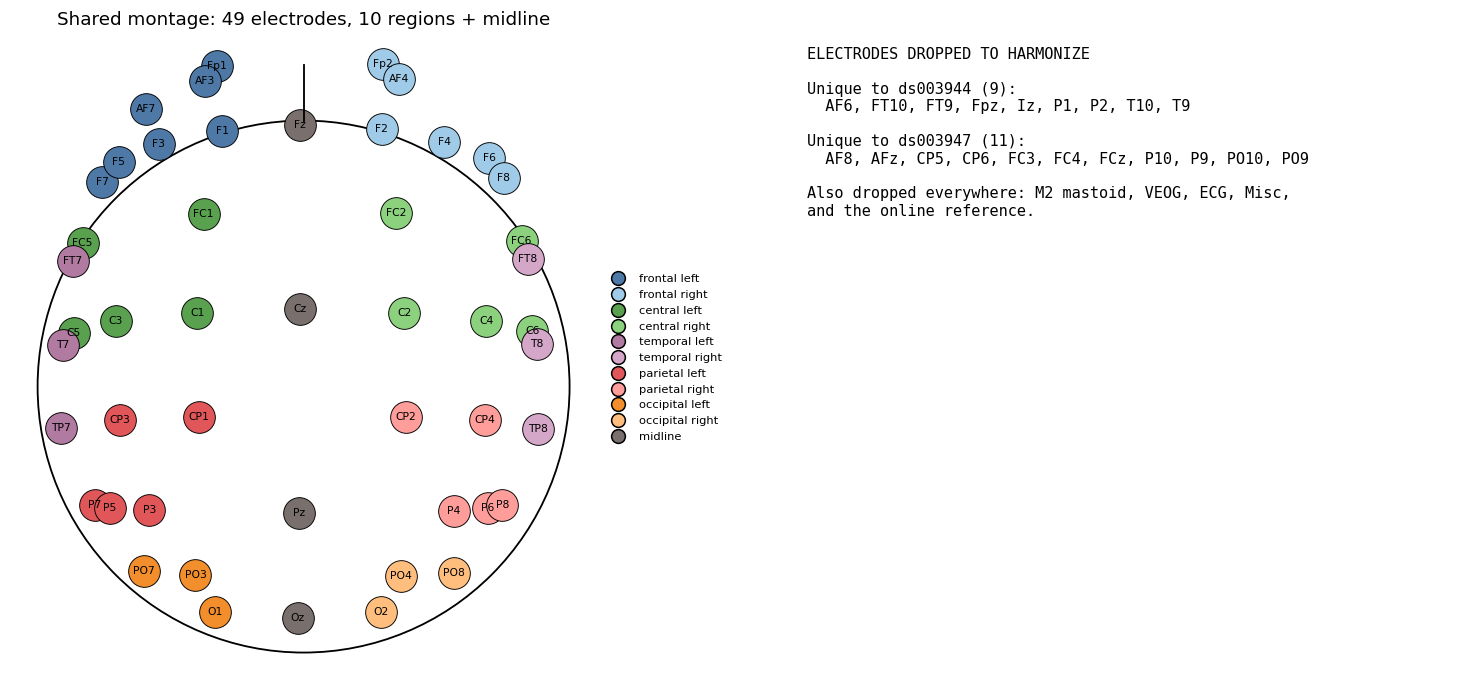

shared cortical electrodes: 49


In [3]:
def eeg_names(ds):
    f = sorted((C.RAW_ROOT / ds).glob("sub-*/eeg/*_channels.tsv"))[0]
    t = pd.read_csv(f, sep="\t")
    return [normalize_name(n) for n, ty in zip(t["name"], t["type"]) if str(ty).upper() == "EEG"]

a, b = set(eeg_names("ds003944")), set(eeg_names("ds003947"))
only_944 = sorted((a - b) - NON_CORTICAL)
only_947 = sorted((b - a) - NON_CORTICAL)

info = mne.create_info(list(COMMON_CORTICAL), 250.0, "eeg"); info.set_montage("standard_1005")
pos = info.get_montage().get_positions()["ch_pos"]
xy = {ch: (pos[ch][0], pos[ch][1]) for ch in COMMON_CORTICAL}
region_of = {ch: reg for reg, chs in REGIONS.items() for ch in chs}
for ch in MIDLINE:
    region_of[ch] = "midline"
region_palette = {
    "frontal_left": "#4e79a7", "frontal_right": "#a0cbe8",
    "central_left": "#59a14f", "central_right": "#8cd17d",
    "temporal_left": "#b07aa1", "temporal_right": "#d4a6c8",
    "parietal_left": "#e15759", "parietal_right": "#ff9d9a",
    "occipital_left": "#f28e2b", "occipital_right": "#ffbe7d", "midline": "#79706e"}

fig, axes = plt.subplots(1, 2, figsize=(15, 6.4), gridspec_kw={"width_ratios": [1.4, 1]})
ax = axes[0]
for ch, (x, y) in xy.items():
    reg = region_of[ch]
    ax.scatter(x, y, s=430, color=region_palette[reg], edgecolor="k", linewidth=0.6, zorder=2)
    ax.text(x, y, ch, ha="center", va="center", fontsize=7, zorder=3)
circle = plt.Circle((0, 0), 0.095, color="k", fill=False, lw=1.2)
ax.add_patch(circle)
ax.plot([0, 0], [0.095, 0.115], "k-", lw=1.2)  # nose
ax.set_aspect("equal"); ax.axis("off")
ax.set_title(f"Shared montage: {len(COMMON_CORTICAL)} electrodes, 10 regions + midline", fontsize=12)
handles = [plt.Line2D([0], [0], marker="o", ls="", markersize=9, markerfacecolor=c,
                      markeredgecolor="k", label=r.replace("_", " "))
           for r, c in region_palette.items()]
ax.legend(handles=handles, loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=7.5, frameon=False)

ax = axes[1]; ax.axis("off")
txt = ("ELECTRODES DROPPED TO HARMONIZE\n\n"
       f"Unique to ds003944 ({len(only_944)}):\n  " + ", ".join(only_944) + "\n\n"
       f"Unique to ds003947 ({len(only_947)}):\n  " + ", ".join(only_947) + "\n\n"
       "Also dropped everywhere: M2 mastoid, VEOG, ECG, Misc,\nand the online reference.")
ax.text(0.0, 0.98, txt, va="top", ha="left", fontsize=10, family="monospace")
fig.tight_layout(); plt.show()
print(f"shared cortical electrodes: {len(COMMON_CORTICAL)}")

## 3. Preprocessing, demonstrated live on one recording

The cleaning is: crop to a common window, band-pass 0.5-45 Hz, resample to 250 Hz, flag bad channels,
remove ocular and cardiac components with picard ICA, interpolate the flagged channels, restrict to the
shared 49, and average-reference. Below we run it end to end on one recording straight from the raw
binary and show the spectral effect of cleaning.

native cortical channels: 58
bad channels flagged/interpolated: ['CP2', 'P1', 'Pz', 'P2']
ICA components removed (ocular/cardiac): [0]
harmonized to 49 channels, average-referenced


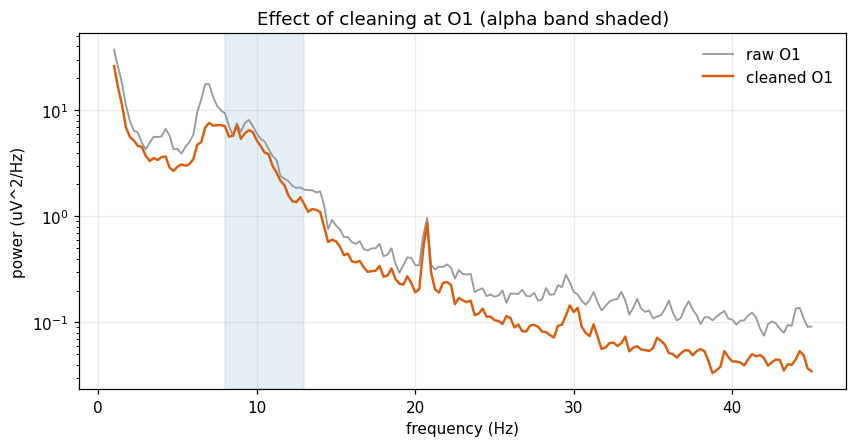

In [4]:
demo = next(r for r in records if r["recording_id"] == "ds003944_sub-1448")
raw_native, native_qc = P._clean_native(demo, cfg, reuse_checkpoint=None)
harm = P.harmonize_to_common(raw_native, cfg)
print(f"native cortical channels: {native_qc['native_channel_count']}")
print(f"bad channels flagged/interpolated: {native_qc['bad_channels']}")
print(f"ICA components removed (ocular/cardiac): {native_qc['ica']['excluded']}")
print(f"harmonized to {len(harm.ch_names)} channels, average-referenced")

# Raw (unfiltered) vs cleaned spectrum at an occipital electrode.
raw0, _ = eeg_io.load_raw(demo)
raw0.pick(["O1"]).crop(3, 297)
p_raw, f_raw = mne.time_frequency.psd_array_welch(raw0.get_data() * 1e6, 1000.0, fmin=1, fmax=45,
                                                  n_fft=4000, verbose="ERROR")
p_cln, f_cln = mne.time_frequency.psd_array_welch(harm.copy().pick(["O1"]).get_data() * 1e6, 250.0,
                                                  fmin=1, fmax=45, n_fft=1000, verbose="ERROR")
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.semilogy(f_raw, p_raw[0], color="#999999", lw=1.2, label="raw O1")
ax.semilogy(f_cln, p_cln[0], color="#d95f0e", lw=1.6, label="cleaned O1")
ax.axvspan(8, 13, alpha=0.12, color="#2c7fb8")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("power (uV^2/Hz)")
ax.set_title("Effect of cleaning at O1 (alpha band shaded)"); ax.legend(frameon=False)
plt.show()

## 4. Cohort preprocessing quality

The full 143-recording run is summarized from the saved per-recording QC. A recording is
feature-eligible when it keeps at least 30 clean 4 s epochs, at most 20 percent bad channels, and at most
60 percent bad epochs.

eligible: 134/143
dataset_id  feature_eligible
ds003944    False                5
            True                77
ds003947    False                4
            True                57


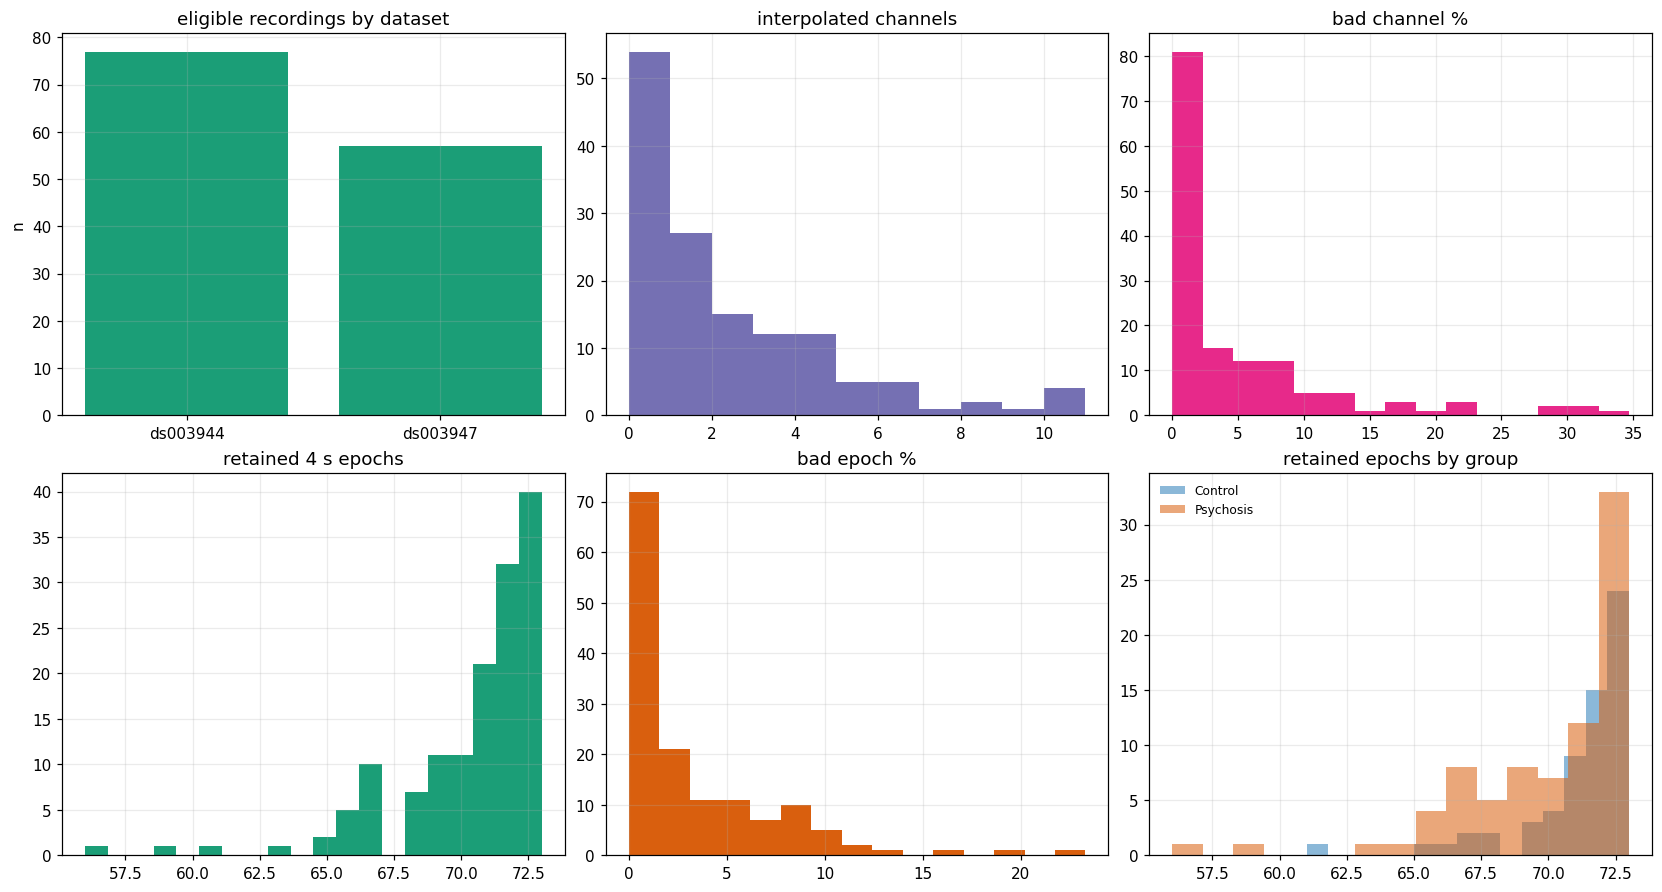

In [5]:
qc_rows = []
for rec in records:
    p = C.SUBJECT_ROOT / rec["recording_id"] / "preprocessing_qc.json"
    q = json.loads(p.read_text()) if p.exists() else {}
    qc_rows.append({"recording_id": rec["recording_id"], "dataset_id": rec["dataset_id"],
                    "feature_eligible": bool(q.get("feature_eligible", False)),
                    "interpolated": q.get("interpolated_channel_count", np.nan),
                    "bad_channel_fraction": q.get("bad_channel_fraction", np.nan),
                    "epochs_retained": q.get("epoch_count_retained", np.nan),
                    "epochs_total": q.get("epoch_count_total", np.nan),
                    "bad_epoch_fraction": q.get("bad_epoch_fraction", np.nan)})
qc = pd.DataFrame(qc_rows).merge(cohort.assign(
    recording_id=lambda d: d["dataset_id"] + "_" + d["participant_id"])[["recording_id", "group"]],
    on="recording_id", how="left")
print(f"eligible: {int(qc['feature_eligible'].sum())}/{len(qc)}")
print(qc.groupby(['dataset_id','feature_eligible']).size().to_string())

fig, ax = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
ax[0,0].bar(*zip(*qc.groupby("dataset_id")["feature_eligible"].sum().items()), color="#1b9e77")
ax[0,0].set_title("eligible recordings by dataset"); ax[0,0].set_ylabel("n")
ax[0,1].hist(qc["interpolated"].dropna(), bins=range(0,12), color="#7570b3"); ax[0,1].set_title("interpolated channels")
ax[0,2].hist(qc["bad_channel_fraction"].dropna()*100, bins=15, color="#e7298a"); ax[0,2].set_title("bad channel %")
ax[1,0].hist(qc["epochs_retained"].dropna(), bins=20, color="#1b9e77"); ax[1,0].set_title("retained 4 s epochs")
ax[1,1].hist(qc["bad_epoch_fraction"].dropna()*100, bins=15, color="#d95f0e"); ax[1,1].set_title("bad epoch %")
for g in ("Control","Psychosis"):
    ax[1,2].hist(qc.loc[qc["group"]==g,"epochs_retained"].dropna(), bins=15, alpha=0.55,
                 color=GROUP_COLORS[g], label=g)
ax[1,2].set_title("retained epochs by group"); ax[1,2].legend(frameon=False, fontsize=8)
plt.show()

## 5. Channel-quality atlas

Per-electrode quality metrics from the bad-channel detector, pooled over the eligible recordings of each
dataset: amplitude (standard deviation) and neighbour correlation. Well-behaved electrodes cluster at
moderate amplitude and high neighbour correlation.

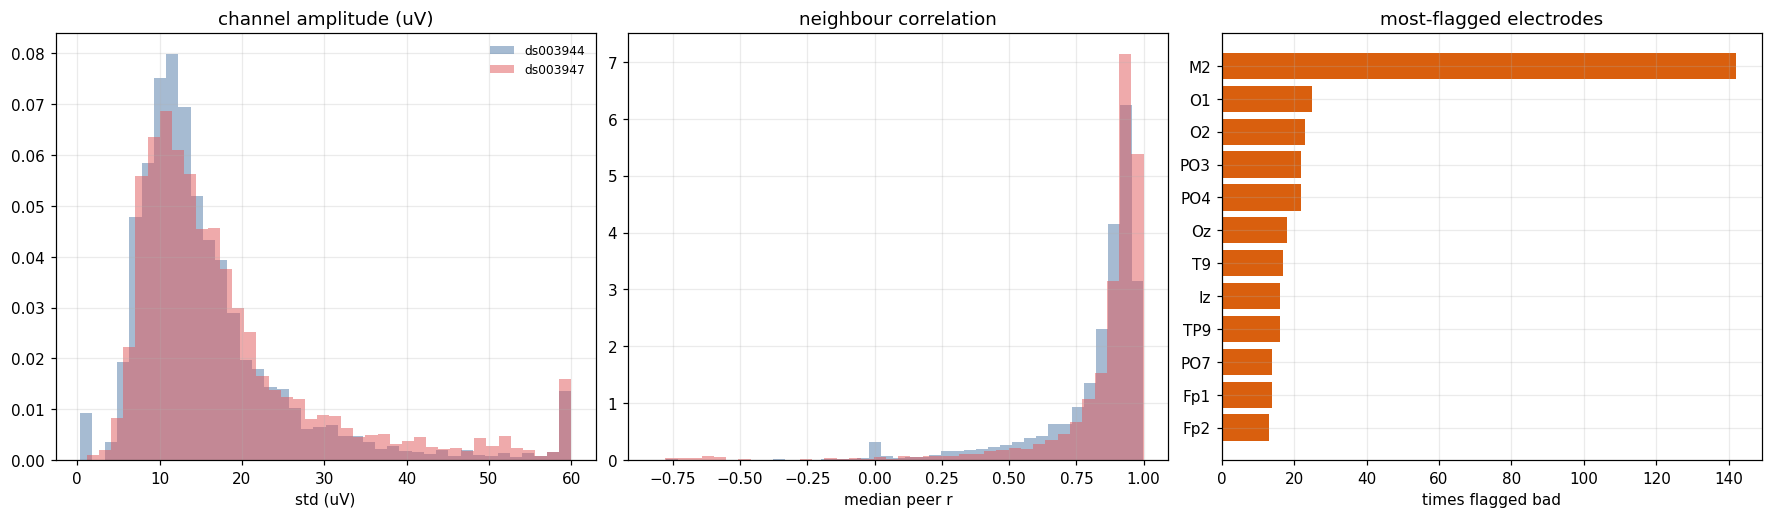

total channel-QC rows: 8723; flagged bad: 624 (7.2%)


In [6]:
ch_frames = []
for rec in records:
    p = C.SUBJECT_ROOT / rec["recording_id"] / "channel_qc.csv"
    if p.exists():
        t = pd.read_csv(p); t["dataset_id"] = rec["dataset_id"]; ch_frames.append(t)
if ch_frames:
    chq = pd.concat(ch_frames, ignore_index=True)
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.6), constrained_layout=True)
    for ds, c in [("ds003944", "#4e79a7"), ("ds003947", "#e15759")]:
        sub = chq[chq["dataset_id"] == ds]
        ax[0].hist(sub["std_uv"].clip(upper=60), bins=40, alpha=0.5, color=c, label=ds, density=True)
        ax[1].hist(sub["median_peer_correlation"].dropna(), bins=40, alpha=0.5, color=c, label=ds, density=True)
    ax[0].set_title("channel amplitude (uV)"); ax[0].set_xlabel("std (uV)"); ax[0].legend(frameon=False, fontsize=8)
    ax[1].set_title("neighbour correlation"); ax[1].set_xlabel("median peer r")
    bad = chq[chq["is_bad"]]
    top_bad = bad["channel"].value_counts().head(12)
    ax[2].barh(top_bad.index[::-1], top_bad.values[::-1], color="#d95f0e")
    ax[2].set_title("most-flagged electrodes"); ax[2].set_xlabel("times flagged bad")
    plt.show()
    print(f"total channel-QC rows: {len(chq)}; flagged bad: {int(chq['is_bad'].sum())} "
          f"({100*chq['is_bad'].mean():.1f}%)")

## 6. Representative cleaned recording

A single harmonized recording: a few seconds of the cleaned trace, the regional power spectra, and the
alpha-band scalp topography. The posterior alpha maximum and the clean spectra confirm the cleaning
worked.

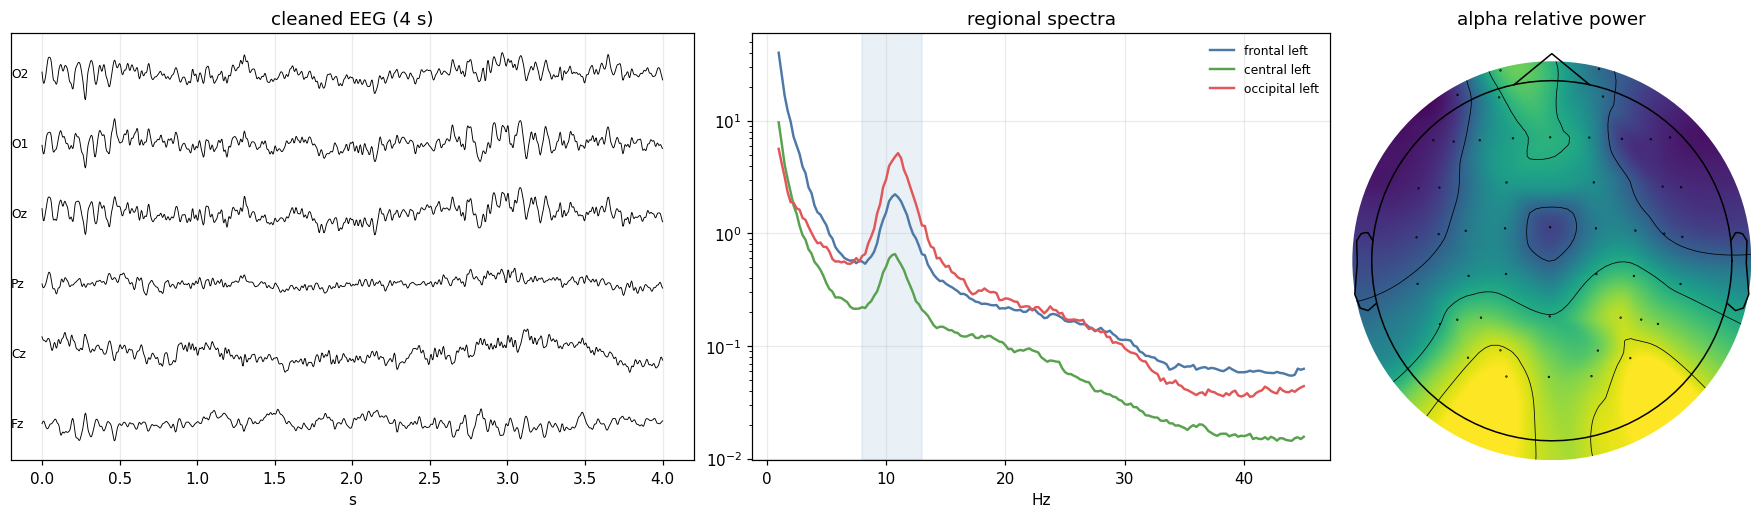

In [7]:
from mne.time_frequency import psd_array_multitaper
from utils.montage import scope_indices
rec = mne.io.read_raw_fif(C.SUBJECT_ROOT / "ds003947_sub-2235A" / "clean_raw.fif", preload=True, verbose="ERROR")
rec.reorder_channels(COMMON_CORTICAL)
info49 = rec.info
epochs = mne.make_fixed_length_epochs(rec, 4.0, preload=True, verbose="ERROR")
psd, freqs = psd_array_multitaper(epochs.get_data(copy=False), 250.0, fmin=1, fmax=45, bandwidth=1.5,
                                  adaptive=False, low_bias=True, normalization="full", output="power",
                                  n_jobs=1, verbose="ERROR")
psd = np.nanmedian(psd, 0) * 1e12

fig = plt.figure(figsize=(16, 4.6), constrained_layout=True)
gs = fig.add_gridspec(1, 3, width_ratios=[1.3, 1.1, 0.8])
ax = fig.add_subplot(gs[0])
seg = rec.copy().crop(40, 44).get_data(picks=["Fz","Cz","Pz","Oz","O1","O2"]) * 1e6
tt = np.arange(seg.shape[1]) / 250.0
for i, ch in enumerate(["Fz","Cz","Pz","Oz","O1","O2"]):
    ax.plot(tt, seg[i] + i*55, "k", lw=0.6); ax.text(-0.2, i*55, ch, fontsize=8, va="center")
ax.set_title("cleaned EEG (4 s)"); ax.set_xlabel("s"); ax.set_yticks([])
ax = fig.add_subplot(gs[1])
for scope, c in [("frontal_left","#4e79a7"),("central_left","#59a14f"),("occipital_left","#e15759")]:
    ax.semilogy(freqs, psd[scope_indices(COMMON_CORTICAL, scope)].mean(0), color=c, lw=1.6,
                label=scope.replace("_"," "))
ax.axvspan(8,13,alpha=0.1,color="#2c7fb8"); ax.set_title("regional spectra"); ax.set_xlabel("Hz"); ax.legend(fontsize=8, frameon=False)
ax = fig.add_subplot(gs[2])
df_ = float(np.median(np.diff(freqs))); amask = (freqs>=8)&(freqs<=13)
alpha_rel = psd[:, amask].sum(1)*df_ / (psd.sum(1)*df_)
mne.viz.plot_topomap(alpha_rel, info49, axes=ax, show=False, cmap="viridis", contours=4)
ax.set_title("alpha relative power")
plt.show()

## 7. Handoff

The harmonized, average-referenced 49-channel checkpoints and their epoch-QC masks are the input to
notebook 02, which extracts the 836 features.

In [8]:
n_elig = int(qc["feature_eligible"].sum())
clean_files = list(C.SUBJECT_ROOT.glob("*/clean_raw.fif"))
print(f"harmonized checkpoints written: {len(clean_files)}")
print(f"feature-eligible recordings:   {n_elig}/{len(records)}")
print(f"shared montage:                {len(COMMON_CORTICAL)} electrodes, 10 regions")
assert len(clean_files) == len(records)
print("\nStage 1 complete. Proceed to 02_EXTRACT_AND_VISUALIZE_EEG_FEATURES.ipynb")

harmonized checkpoints written: 143
feature-eligible recordings:   134/143
shared montage:                49 electrodes, 10 regions

Stage 1 complete. Proceed to 02_EXTRACT_AND_VISUALIZE_EEG_FEATURES.ipynb
